# Árvore de Decisão para Detecção de Alzheimer

## Objetivo
Este notebook implementa um **classificador de Árvore de Decisão (Decision Tree)** otimizado para classificação binária, com o objetivo de determinar se um paciente tem Alzheimer ou não.

## Sobre Árvores de Decisão
A Árvore de Decisão é um algoritmo que cria um modelo de decisões em forma de árvore, onde cada nó interno representa um "teste" em um atributo, cada ramo representa o resultado do teste, e cada folha representa uma classe.

### Características das Árvores de Decisão:
- **Interpretável**: Fácil de visualizar e entender as regras de decisão
- **Não requer normalização**: Insensível à escala dos dados
- **Importância de Features**: Identifica quais variáveis são mais importantes
- **Risco de Overfitting**: Pode criar árvores muito complexas

## Métricas Importantes para Diagnóstico Médico
- **Recall (Sensibilidade)**: Capacidade de identificar corretamente os casos positivos (doentes)
- **Precisão**: Proporção de diagnósticos positivos que são realmente corretos
- **F1-Score**: Média harmônica entre precisão e recall
- **AUC-ROC**: Área sob a curva ROC

## 1. Importação das Bibliotecas

In [1]:
# ==============================================================================
# IMPORTAÇÃO DE BIBLIOTECAS
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree  # Árvore de Decisão
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_curve, 
    auc, 
    precision_recall_curve,
    accuracy_score,
    f1_score,
    recall_score,
    precision_score
)

# Balanceamento
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Carregamento e Exploração dos Dados

In [2]:
# ==============================================================================
# CARREGAMENTO DOS DADOS
# ==============================================================================

import os

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    csv_path = '/content/drive/MyDrive/alzheimers_disease_data.csv'
    print('Rodando no Google Colab')
except ImportError:
    print('Rodando localmente - Selecione o arquivo CSV')
    import tkinter as tk
    from tkinter import filedialog
    
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    
    csv_path = filedialog.askopenfilename(
        title='Selecione o arquivo alzheimers_disease_data.csv',
        filetypes=[('CSV files', '*.csv'), ('All files', '*.*')]
    )
    root.destroy()
    
    if not csv_path:
        raise FileNotFoundError('Nenhum arquivo selecionado!')

df = pd.read_csv(csv_path)

print(f'Dataset carregado com sucesso!')
print(f'Dimensões: {df.shape[0]} amostras x {df.shape[1]} features')

Rodando localmente - Selecione o arquivo CSV
Dataset carregado com sucesso!
Dimensões: 2149 amostras x 35 features


In [3]:
# ==============================================================================
# EXPLORAÇÃO INICIAL
# ==============================================================================

print("=" * 60)
print("PRIMEIRAS LINHAS DO DATASET")
print("=" * 60)
display(df.head())

print("\n" + "=" * 60)
print("INFORMAÇÕES DO DATASET")
print("=" * 60)
print(df.info())

PRIMEIRAS LINHAS DO DATASET


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid



INFORMAÇÕES DO DATASET
<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non

## 3. Pré-processamento dos Dados

In [4]:
# ==============================================================================
# PRÉ-PROCESSAMENTO
# ==============================================================================

# Remoção de colunas irrelevantes
colunas_remover = ['PatientID', 'DoctorInCharge']
df = df.drop(columns=colunas_remover)
print(f"Colunas removidas: {colunas_remover}")
print(f"Novas dimensões: {df.shape}")

# Verificação de valores nulos e duplicatas
print(f"\nValores nulos: {df.isnull().sum().sum()}")
print(f"Linhas duplicadas: {df.duplicated().sum()}")

Colunas removidas: ['PatientID', 'DoctorInCharge']
Novas dimensões: (2149, 33)

Valores nulos: 0
Linhas duplicadas: 0


## 4. Análise da Variável Alvo

Distribuição da variável alvo:
  - Saudável (0): 1389 (64.6%)
  - Com Alzheimer (1): 760 (35.4%)


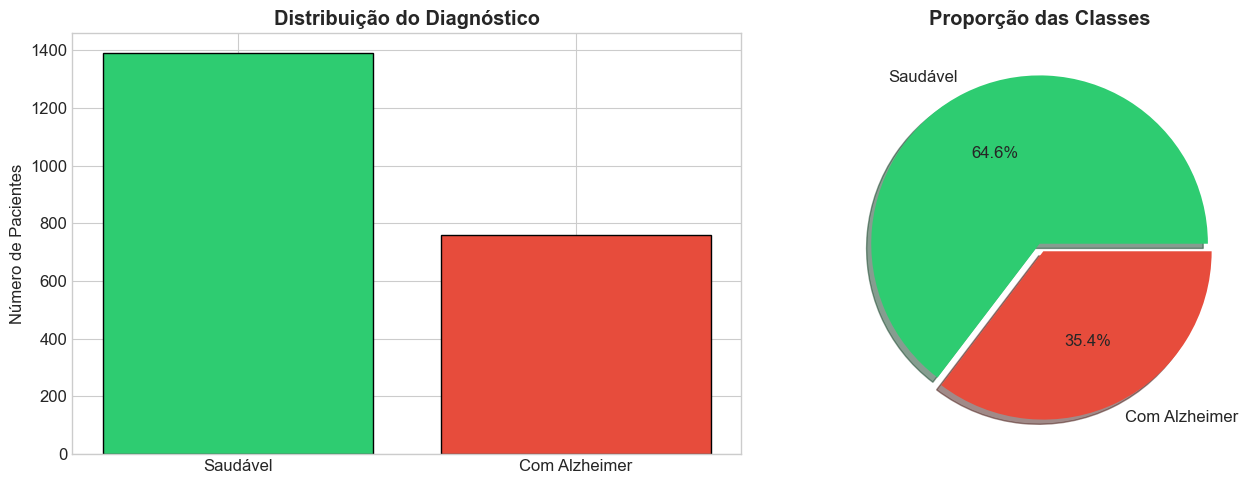

In [5]:
# ==============================================================================
# ANÁLISE DA VARIÁVEL ALVO
# ==============================================================================

contagem_classes = df['Diagnosis'].value_counts()
print("Distribuição da variável alvo:")
print(f"  - Saudável (0): {contagem_classes[0]} ({contagem_classes[0]/len(df)*100:.1f}%)")
print(f"  - Com Alzheimer (1): {contagem_classes[1]} ({contagem_classes[1]/len(df)*100:.1f}%)")

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#e74c3c']

bars = axes[0].bar(['Saudável', 'Com Alzheimer'], 
                   [contagem_classes[0], contagem_classes[1]], 
                   color=colors, edgecolor='black')
axes[0].set_title('Distribuição do Diagnóstico', fontweight='bold')
axes[0].set_ylabel('Número de Pacientes')

axes[1].pie([contagem_classes[0], contagem_classes[1]], 
            labels=['Saudável', 'Com Alzheimer'],
            autopct='%1.1f%%', colors=colors, explode=(0, 0.05), shadow=True)
axes[1].set_title('Proporção das Classes', fontweight='bold')

plt.tight_layout()
plt.savefig('dt_distribuicao_classes.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Balanceamento e Preparação dos Dados

In [6]:
# ==============================================================================
# SEPARAÇÃO E BALANCEAMENTO
# ==============================================================================

X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

# SMOTE para balanceamento
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_balanced, y_balanced = smote.fit_resample(X, y)

print(f"Após SMOTE: {len(y_balanced)} amostras")
print(f"  - Classe 0: {sum(y_balanced == 0)}")
print(f"  - Classe 1: {sum(y_balanced == 1)}")

Após SMOTE: 2778 amostras
  - Classe 0: 1389
  - Classe 1: 1389


In [7]:
# ==============================================================================
# DIVISÃO TREINO/TESTE
# ==============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, 
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_balanced
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

# Guardar nomes das features para visualização
feature_names = X.columns.tolist()

Treino: 2083 amostras
Teste: 695 amostras


## 6. Modelo Árvore de Decisão Base

In [8]:
# ==============================================================================
# MODELO BASE (SEM LIMITAÇÕES - RISCO DE OVERFITTING)
# ==============================================================================

print("=" * 60)
print("MODELO ÁRVORE DE DECISÃO BASE")
print("=" * 60)

# Árvore sem limitações (vai crescer até memorizar os dados)
dt_base = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_base.fit(X_train, y_train)

y_pred_base = dt_base.predict(X_test)
y_proba_base = dt_base.predict_proba(X_test)[:, 1]

acc_base = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base)
rec_base = recall_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)

print(f"\nResultados do Modelo Base (Sem Poda):")
print(f"  Acurácia:  {acc_base*100:.2f}%")
print(f"  Precisão:  {prec_base*100:.2f}%")
print(f"  Recall:    {rec_base*100:.2f}%")
print(f"  F1-Score:  {f1_base*100:.2f}%")
print(f"\n  Profundidade da árvore: {dt_base.get_depth()}")
print(f"  Número de folhas: {dt_base.get_n_leaves()}")

# Comparar treino vs teste (indicador de overfitting)
acc_train_base = dt_base.score(X_train, y_train)
print(f"\n  Acurácia no Treino: {acc_train_base*100:.2f}%")
print(f"  Acurácia no Teste:  {acc_base*100:.2f}%")
if acc_train_base - acc_base > 0.1:
    print(f"  ALERTA: Diferença de {(acc_train_base-acc_base)*100:.1f}% sugere OVERFITTING!")

MODELO ÁRVORE DE DECISÃO BASE

Resultados do Modelo Base (Sem Poda):
  Acurácia:  83.02%
  Precisão:  82.44%
  Recall:    83.86%
  F1-Score:  83.14%

  Profundidade da árvore: 16
  Número de folhas: 185

  Acurácia no Treino: 100.00%
  Acurácia no Teste:  83.02%
  ALERTA: Diferença de 17.0% sugere OVERFITTING!


## 7. GridSearch para Otimização (Poda da Árvore)

Para evitar overfitting, precisamos **podar** a árvore limitando:
- `max_depth`: Profundidade máxima
- `min_samples_split`: Mínimo de amostras para dividir um nó
- `min_samples_leaf`: Mínimo de amostras em cada folha
- `max_features`: Número de features a considerar em cada divisão

In [9]:
# ==============================================================================
# GRIDSEARCH PARA OTIMIZAÇÃO (PODA)
# ==============================================================================

print("=" * 60)
print("GRIDSEARCH - OTIMIZAÇÃO DE HIPERPARÂMETROS")
print("=" * 60)

param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None]
}

print("\nGrade de hiperparâmetros:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("\nExecutando GridSearch...")
grid_search.fit(X_train, y_train)

print(f"\n" + "=" * 60)
print("MELHORES HIPERPARÂMETROS ENCONTRADOS:")
print("=" * 60)
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMelhor F1-Score (CV): {grid_search.best_score_*100:.2f}%")

GRIDSEARCH - OTIMIZAÇÃO DE HIPERPARÂMETROS

Grade de hiperparâmetros:
  max_depth: [3, 5, 7, 10, 15, None]
  min_samples_split: [2, 5, 10, 20]
  min_samples_leaf: [1, 2, 5, 10]
  criterion: ['gini', 'entropy']
  max_features: ['sqrt', 'log2', None]

Executando GridSearch...
Fitting 5 folds for each of 576 candidates, totalling 2880 fits

MELHORES HIPERPARÂMETROS ENCONTRADOS:
  criterion: entropy
  max_depth: 5
  max_features: None
  min_samples_leaf: 5
  min_samples_split: 20

Melhor F1-Score (CV): 88.40%


## 8. Modelo Final Otimizado

In [10]:
# ==============================================================================
# MODELO FINAL OTIMIZADO
# ==============================================================================

print("=" * 60)
print("AVALIAÇÃO DO MODELO OTIMIZADO")
print("=" * 60)

dt_otimizado = grid_search.best_estimator_

y_pred = dt_otimizado.predict(X_test)
y_proba = dt_otimizado.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nMétricas no Conjunto de Teste:")
print(f"  Acurácia:  {accuracy*100:.2f}%")
print(f"  Precisão:  {precision*100:.2f}%")
print(f"  Recall:    {recall*100:.2f}%")
print(f"  F1-Score:  {f1*100:.2f}%")
print(f"\n  Profundidade da árvore: {dt_otimizado.get_depth()}")
print(f"  Número de folhas: {dt_otimizado.get_n_leaves()}")

# Relatório completo
print("\n" + "=" * 60)
print("RELATÓRIO DE CLASSIFICAÇÃO DETALHADO")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Saudável', 'Alzheimer']))

AVALIAÇÃO DO MODELO OTIMIZADO

Métricas no Conjunto de Teste:
  Acurácia:  89.78%
  Precisão:  97.59%
  Recall:    81.56%
  F1-Score:  88.85%

  Profundidade da árvore: 5
  Número de folhas: 27

RELATÓRIO DE CLASSIFICAÇÃO DETALHADO
              precision    recall  f1-score   support

    Saudável       0.84      0.98      0.91       348
   Alzheimer       0.98      0.82      0.89       347

    accuracy                           0.90       695
   macro avg       0.91      0.90      0.90       695
weighted avg       0.91      0.90      0.90       695



## 9. Comparação: Base vs Otimizado

COMPARAÇÃO: MODELO BASE vs MODELO OTIMIZADO (PODADO)

Métrica              Base (Sem Poda)      Otimizado            Diferença      
---------------------------------------------------------------------------
Acurácia                         83.02%             89.78%        +6.76%
Precisão                         82.44%             97.59%       +15.15%
Recall                           83.86%             81.56%        -2.31%
F1-Score                         83.14%             88.85%        +5.71%
Profundidade                        16                 5
Folhas                             185                27


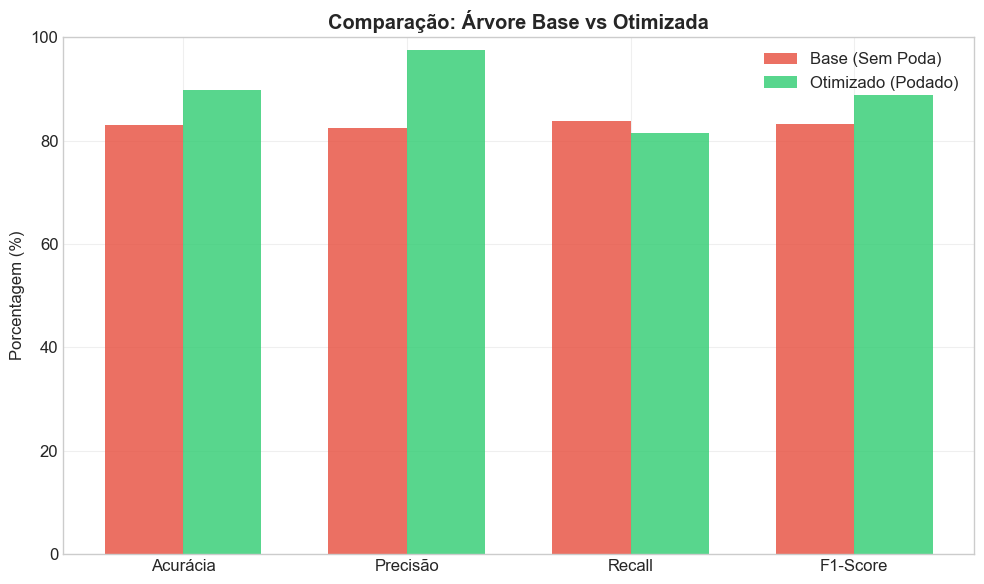

In [11]:
# ==============================================================================
# COMPARAÇÃO BASE vs OTIMIZADO
# ==============================================================================

print("=" * 70)
print("COMPARAÇÃO: MODELO BASE vs MODELO OTIMIZADO (PODADO)")
print("=" * 70)

print(f"\n{'Métrica':<20} {'Base (Sem Poda)':<20} {'Otimizado':<20} {'Diferença':<15}")
print("-" * 75)
print(f"{'Acurácia':<20} {acc_base*100:>17.2f}% {accuracy*100:>17.2f}% {(accuracy-acc_base)*100:>+12.2f}%")
print(f"{'Precisão':<20} {prec_base*100:>17.2f}% {precision*100:>17.2f}% {(precision-prec_base)*100:>+12.2f}%")
print(f"{'Recall':<20} {rec_base*100:>17.2f}% {recall*100:>17.2f}% {(recall-rec_base)*100:>+12.2f}%")
print(f"{'F1-Score':<20} {f1_base*100:>17.2f}% {f1*100:>17.2f}% {(f1-f1_base)*100:>+12.2f}%")
print(f"{'Profundidade':<20} {dt_base.get_depth():>17} {dt_otimizado.get_depth():>17}")
print(f"{'Folhas':<20} {dt_base.get_n_leaves():>17} {dt_otimizado.get_n_leaves():>17}")

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))

metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
valores_base = [acc_base*100, prec_base*100, rec_base*100, f1_base*100]
valores_otim = [accuracy*100, precision*100, recall*100, f1*100]

x = np.arange(len(metricas))
width = 0.35

bars1 = ax.bar(x - width/2, valores_base, width, label='Base (Sem Poda)', color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + width/2, valores_otim, width, label='Otimizado (Podado)', color='#2ecc71', alpha=0.8)

ax.set_ylabel('Porcentagem (%)')
ax.set_title('Comparação: Árvore Base vs Otimizada', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.legend()
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dt_comparacao_gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Importância das Features

Uma grande vantagem das Árvores de Decisão é a capacidade de identificar quais variáveis são mais importantes para a classificação.

IMPORTÂNCIA DAS FEATURES
   1. ADL                           : 25.66%
   2. MMSE                          : 23.04%
   3. FunctionalAssessment          : 22.42%
   4. MemoryComplaints              : 11.22%
   5. BehavioralProblems            : 10.12%
   6. Depression                    : 1.69%
   7. CholesterolHDL                : 1.07%
   8. SleepQuality                  : 1.00%
   9. PhysicalActivity              : 0.71%
  10. Age                           : 0.57%
  11. CholesterolLDL                : 0.53%
  12. CholesterolTotal              : 0.52%
  13. CholesterolTriglycerides      : 0.43%
  14. EducationLevel                : 0.40%
  15. DietQuality                   : 0.36%


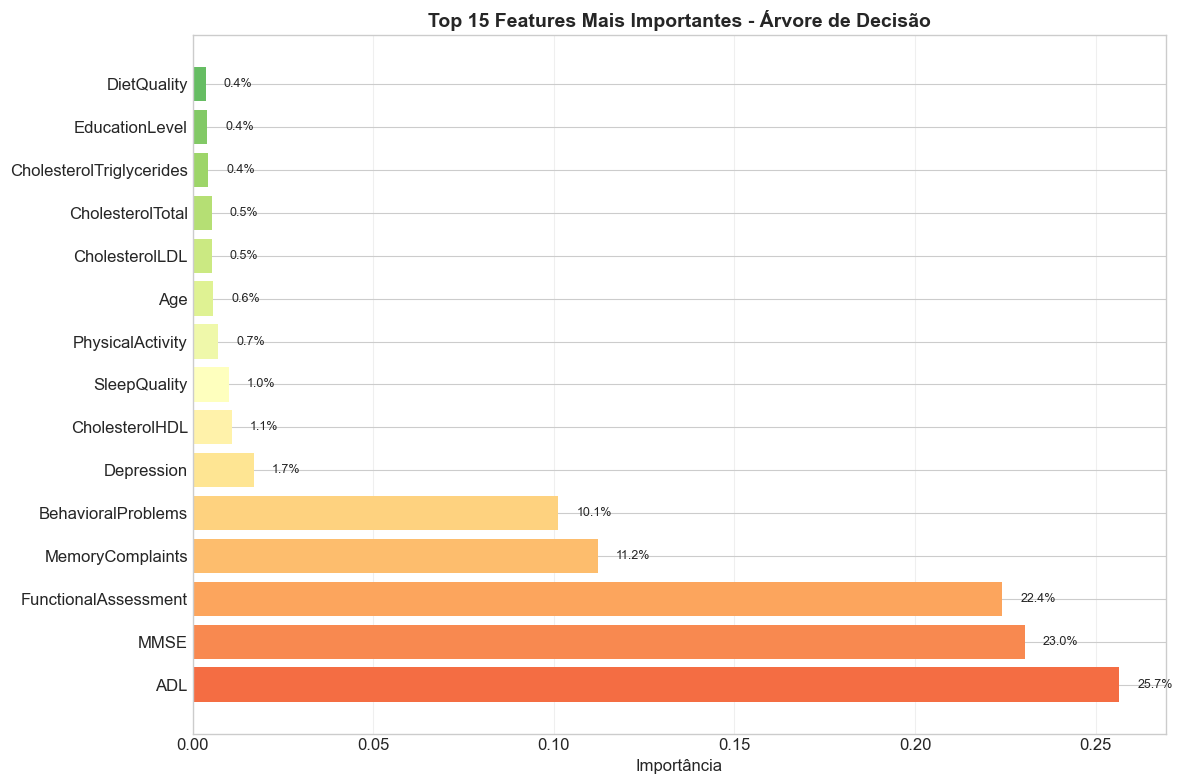

In [12]:
# ==============================================================================
# IMPORTÂNCIA DAS FEATURES
# ==============================================================================

importances = dt_otimizado.feature_importances_
indices = np.argsort(importances)[::-1]

print("=" * 60)
print("IMPORTÂNCIA DAS FEATURES")
print("=" * 60)

for i, idx in enumerate(indices[:15], 1):
    print(f"  {i:2d}. {feature_names[idx]:30s}: {importances[idx]*100:.2f}%")

# Gráfico
plt.figure(figsize=(12, 8))
top_n = 15
top_indices = indices[:top_n]

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, top_n))[::-1]

bars = plt.barh(range(top_n), importances[top_indices][::-1], color=colors)
plt.yticks(range(top_n), [feature_names[i] for i in top_indices[::-1]])
plt.xlabel('Importância', fontsize=12)
plt.title('Top 15 Features Mais Importantes - Árvore de Decisão', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')

# Adicionar valores
for i, bar in enumerate(bars):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{importances[top_indices[::-1][i]]*100:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('dt_importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Visualização da Árvore de Decisão

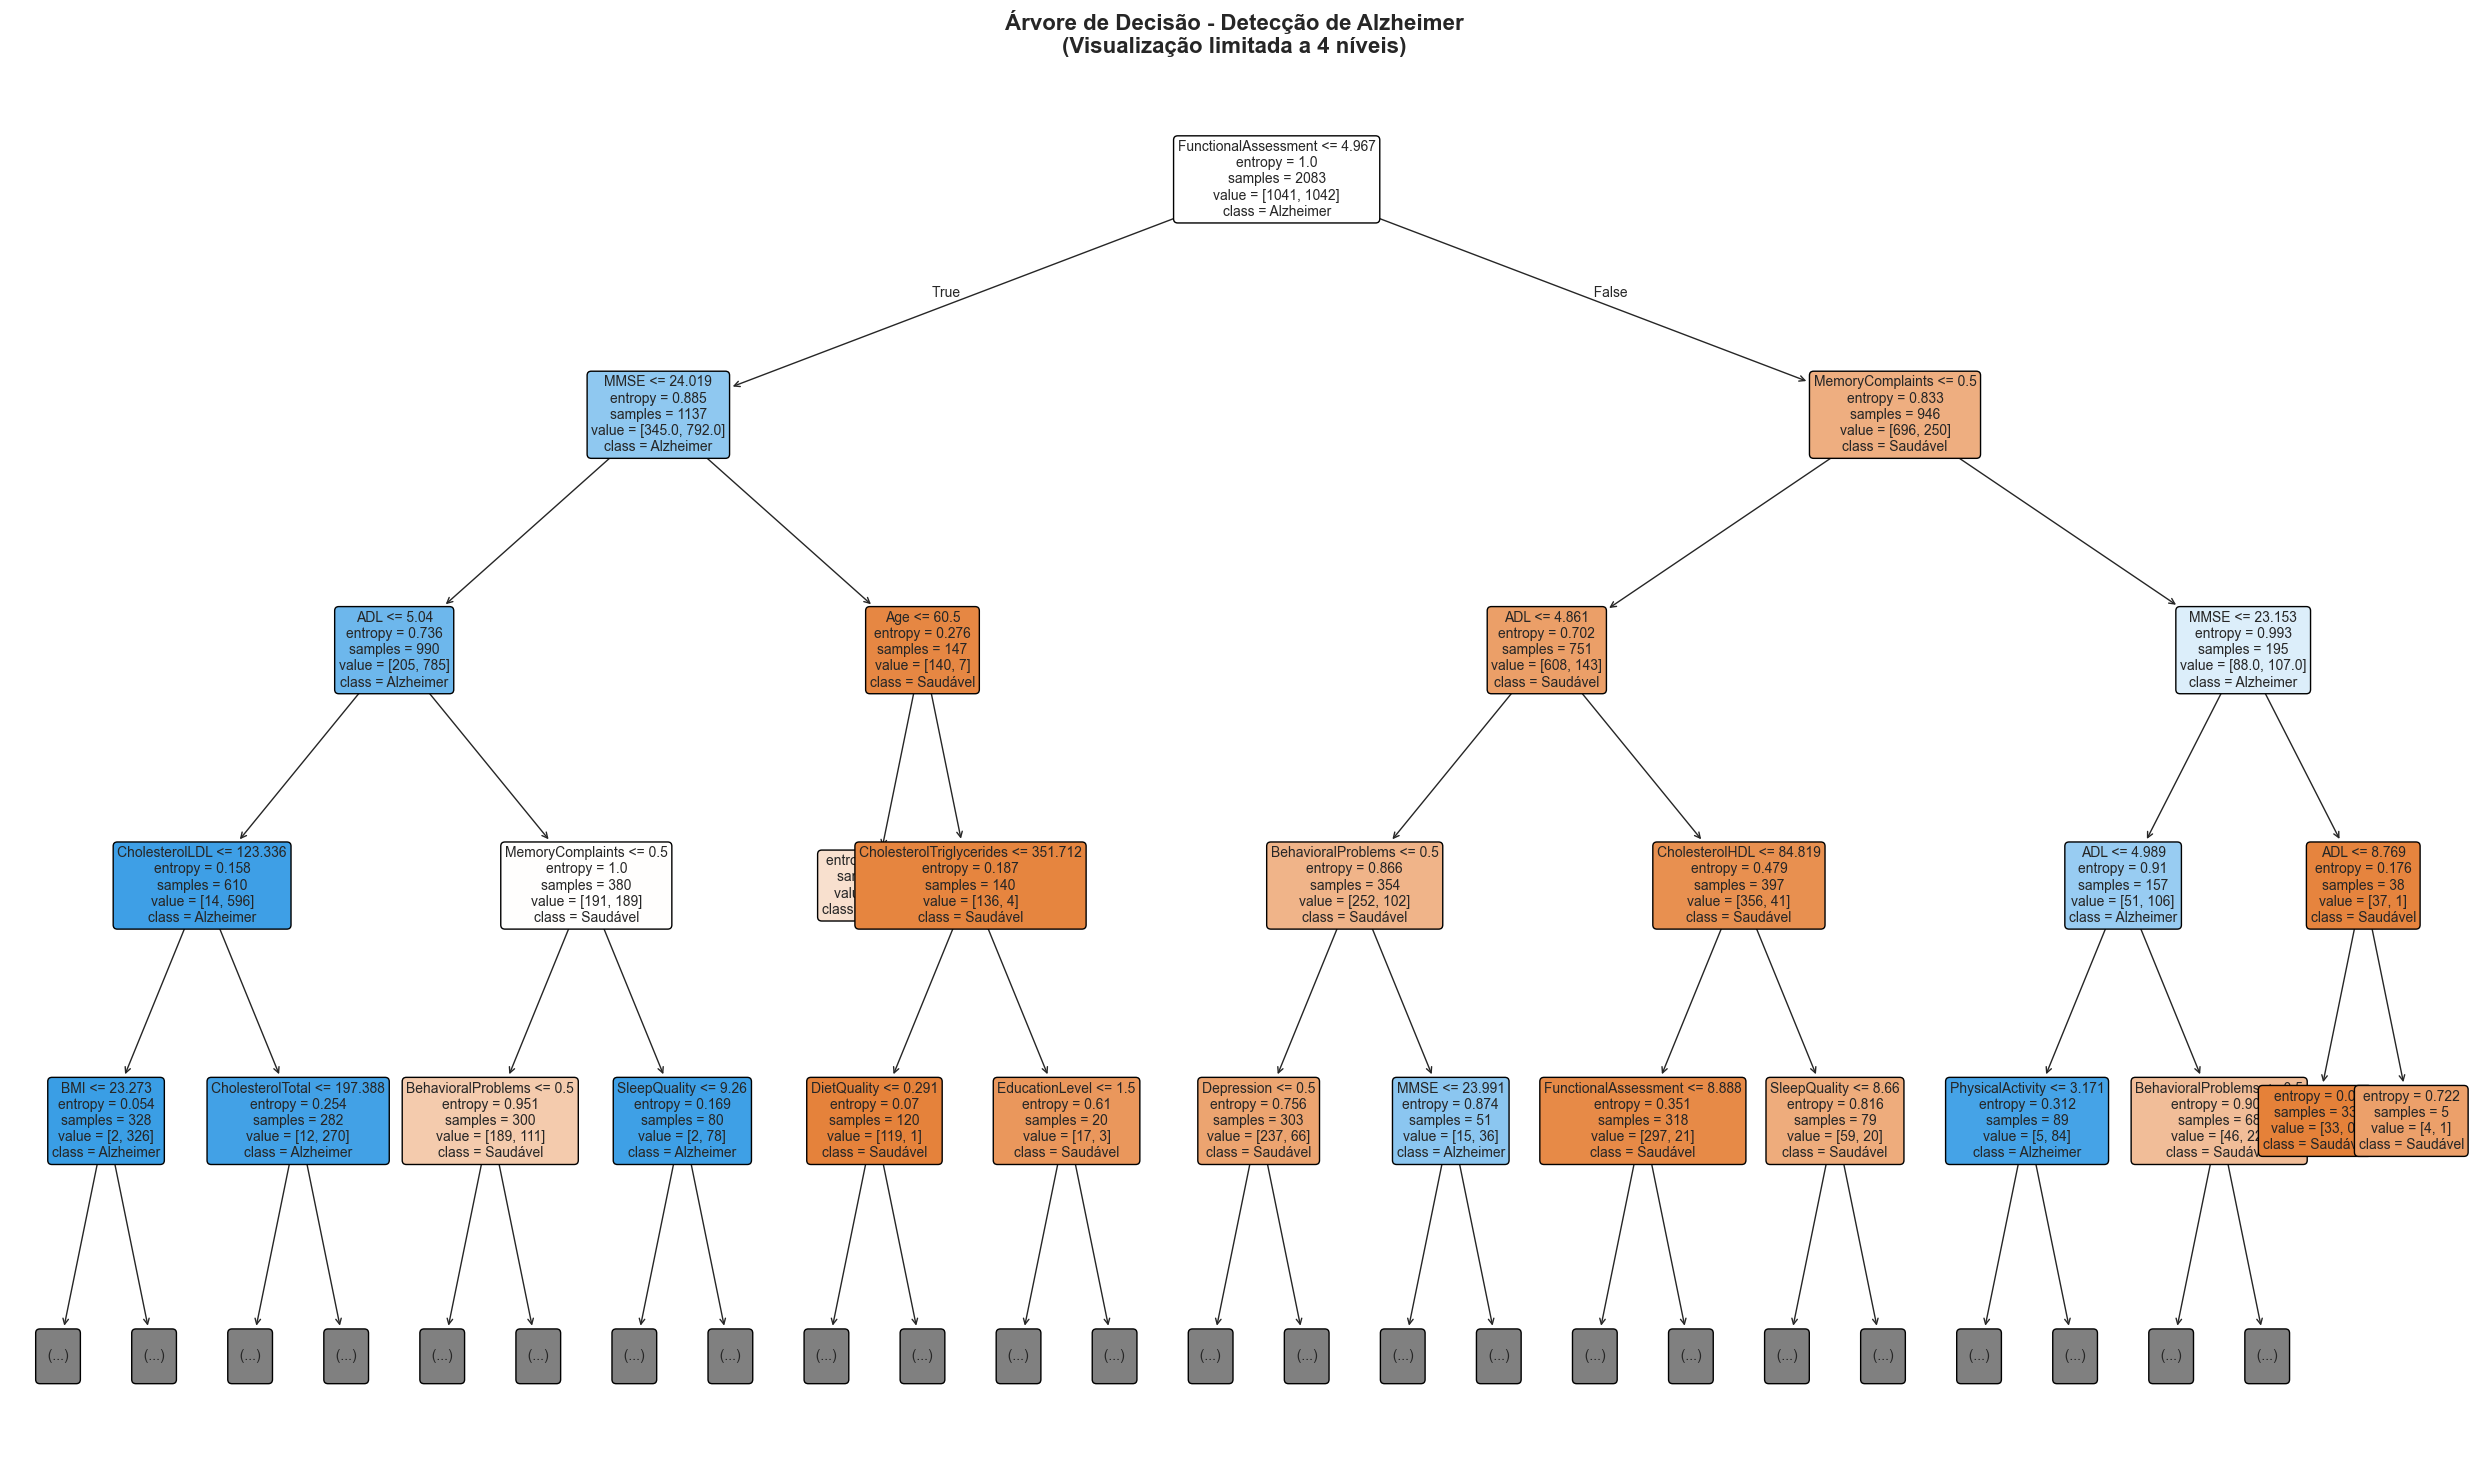


Nota: A visualização está limitada a 4 níveis para melhor clareza.
A árvore completa tem 5 níveis.


In [13]:
# ==============================================================================
# VISUALIZAÇÃO DA ÁRVORE
# ==============================================================================

plt.figure(figsize=(25, 15))
plot_tree(dt_otimizado, 
          feature_names=feature_names,
          class_names=['Saudável', 'Alzheimer'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=4)  # Limitando visualização para clareza

plt.title('Árvore de Decisão - Detecção de Alzheimer\n(Visualização limitada a 4 níveis)', 
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_arvore_visualizacao.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNota: A visualização está limitada a 4 níveis para melhor clareza.")
print(f"A árvore completa tem {dt_otimizado.get_depth()} níveis.")

## 12. Matriz de Confusão e Curvas

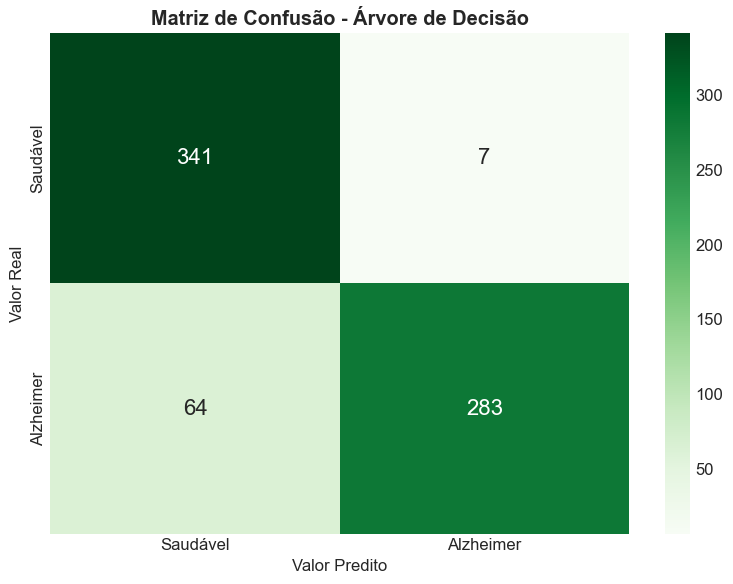


Análise:
  TN: 341, TP: 283, FP: 7, FN: 64


In [14]:
# ==============================================================================
# MATRIZ DE CONFUSÃO
# ==============================================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Saudável', 'Alzheimer'],
            yticklabels=['Saudável', 'Alzheimer'],
            annot_kws={'size': 16})
plt.title('Matriz de Confusão - Árvore de Decisão', fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predito')
plt.tight_layout()
plt.savefig('dt_matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nAnálise:")
print(f"  TN: {tn}, TP: {tp}, FP: {fp}, FN: {fn}")

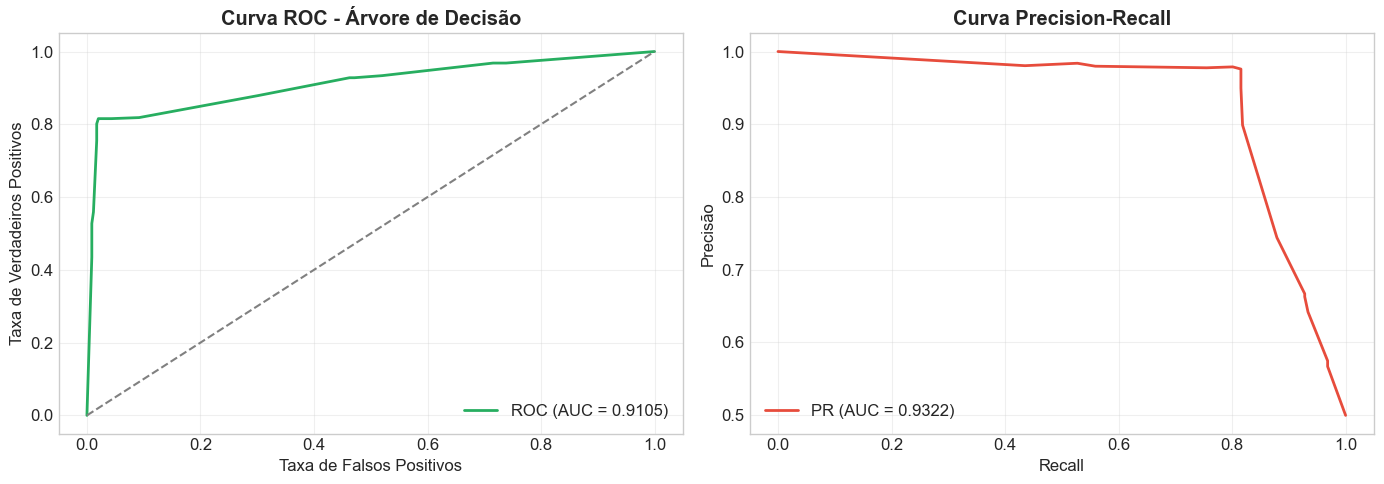

AUC-ROC: 0.9105
AUC-PR: 0.9322


In [15]:
# ==============================================================================
# CURVAS ROC E PRECISION-RECALL
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='#27ae60', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_xlabel('Taxa de Falsos Positivos')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos')
axes[0].set_title('Curva ROC - Árvore de Decisão', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# PR
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_curve, precision_curve)

axes[1].plot(recall_curve, precision_curve, color='#e74c3c', lw=2, label=f'PR (AUC = {pr_auc:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precisão')
axes[1].set_title('Curva Precision-Recall', fontweight='bold')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dt_curvas_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC-ROC: {roc_auc:.4f}")
print(f"AUC-PR: {pr_auc:.4f}")

## 13. Conclusão

In [16]:
# ==============================================================================
# RESUMO FINAL
# ==============================================================================

print("=" * 70)
print("RESUMO FINAL - ÁRVORE DE DECISÃO PARA DETECÇÃO DE ALZHEIMER")
print("=" * 70)

print(f"\nMelhores Hiperparâmetros:")
for param, value in grid_search.best_params_.items():
    print(f"  - {param}: {value}")

print(f"\nDesempenho Final:")
print(f"  - Acurácia:  {accuracy*100:.2f}%")
print(f"  - Precisão:  {precision*100:.2f}%")
print(f"  - Recall:    {recall*100:.2f}%")
print(f"  - F1-Score:  {f1*100:.2f}%")
print(f"  - AUC-ROC:   {roc_auc:.4f}")

print(f"\nTop 5 Features Mais Importantes:")
for i, idx in enumerate(indices[:5], 1):
    print(f"  {i}. {feature_names[idx]} ({importances[idx]*100:.1f}%)")

print("\n" + "=" * 70)
print("VANTAGENS DA ÁRVORE DE DECISÃO:")
print("=" * 70)
print("""
  1. INTERPRETABILIDADE: Regras de decisão claras e visualizáveis
  2. NÃO REQUER NORMALIZAÇÃO: Insensível à escala dos dados
  3. IMPORTÂNCIA DE FEATURES: Identifica variáveis mais relevantes
  4. LIDA COM NÃO-LINEARIDADE: Captura relações complexas
""")

print("LIMITAÇÕES:")
print("""
  1. OVERFITTING: Tendência a memorizar dados sem poda adequada
  2. INSTABILIDADE: Pequenas mudanças nos dados podem mudar a árvore
  3. VIÉS: Tende a favorecer features com mais níveis
  4. BORDAS RETILÍNEAS: Fronteiras de decisão sempre perpendiculares
""")

RESUMO FINAL - ÁRVORE DE DECISÃO PARA DETECÇÃO DE ALZHEIMER

Melhores Hiperparâmetros:
  - criterion: entropy
  - max_depth: 5
  - max_features: None
  - min_samples_leaf: 5
  - min_samples_split: 20

Desempenho Final:
  - Acurácia:  89.78%
  - Precisão:  97.59%
  - Recall:    81.56%
  - F1-Score:  88.85%
  - AUC-ROC:   0.9105

Top 5 Features Mais Importantes:
  1. ADL (25.7%)
  2. MMSE (23.0%)
  3. FunctionalAssessment (22.4%)
  4. MemoryComplaints (11.2%)
  5. BehavioralProblems (10.1%)

VANTAGENS DA ÁRVORE DE DECISÃO:

  1. INTERPRETABILIDADE: Regras de decisão claras e visualizáveis
  2. NÃO REQUER NORMALIZAÇÃO: Insensível à escala dos dados
  3. IMPORTÂNCIA DE FEATURES: Identifica variáveis mais relevantes
  4. LIDA COM NÃO-LINEARIDADE: Captura relações complexas

LIMITAÇÕES:

  1. OVERFITTING: Tendência a memorizar dados sem poda adequada
  2. INSTABILIDADE: Pequenas mudanças nos dados podem mudar a árvore
  3. VIÉS: Tende a favorecer features com mais níveis
  4. BORDAS RETILÍNE